# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('/content/neo.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Target value counts ('hazardous'):\n", df['hazardous'].value_counts())
print("\nUnique values in non-numeric cols:")
for col in df.select_dtypes(include=['object', 'bool']).columns:
    print(f"{col}: {df[col].nunique()} unique values, sample: {df[col].unique()[:5]}")


Shape: (90836, 10)
Columns: ['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous']
Target value counts ('hazardous'):
 hazardous
False    81996
True      8840
Name: count, dtype: int64

Unique values in non-numeric cols:
name: 27423 unique values, sample: ['162635 (2000 SS164)' '277475 (2005 WK4)' '512244 (2015 YE18)'
 '(2012 BV13)' '(2014 GE35)']
orbiting_body: 1 unique values, sample: ['Earth']
sentry_object: 1 unique values, sample: [False]
hazardous: 2 unique values, sample: [False  True]


In [3]:


cols_to_drop = [ 'orbiting_body', 'sentry_object']

df_cleaned = df.drop(columns=cols_to_drop)

print("Remaining columns after dropping:")
print(df_cleaned.columns.tolist())

print(f"\nOriginal shape: {df.shape}")
print(f"Cleaned shape:  {df_cleaned.shape}")

Remaining columns after dropping:
['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous']

Original shape: (90836, 10)
Cleaned shape:  (90836, 8)


In [4]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


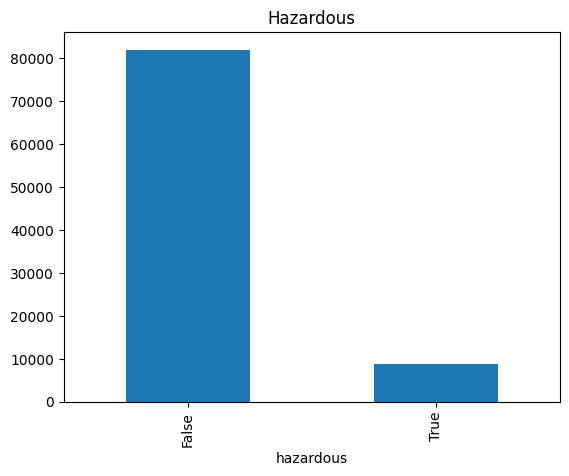

In [5]:
df.hazardous.value_counts().plot(kind='bar')
plt.title('Hazardous')
plt.show()

The dataset exhibits a severe class imbalance (~90% False vs. ~10% True), meaning hazardous space objects are extremely rare and require specialized modeling techniques to detect accurately.

In [6]:
numeric_df = ["est_diameter_min","est_diameter_max","relative_velocity","miss_distance","absolute_magnitude"]
df[numeric_df].describe()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


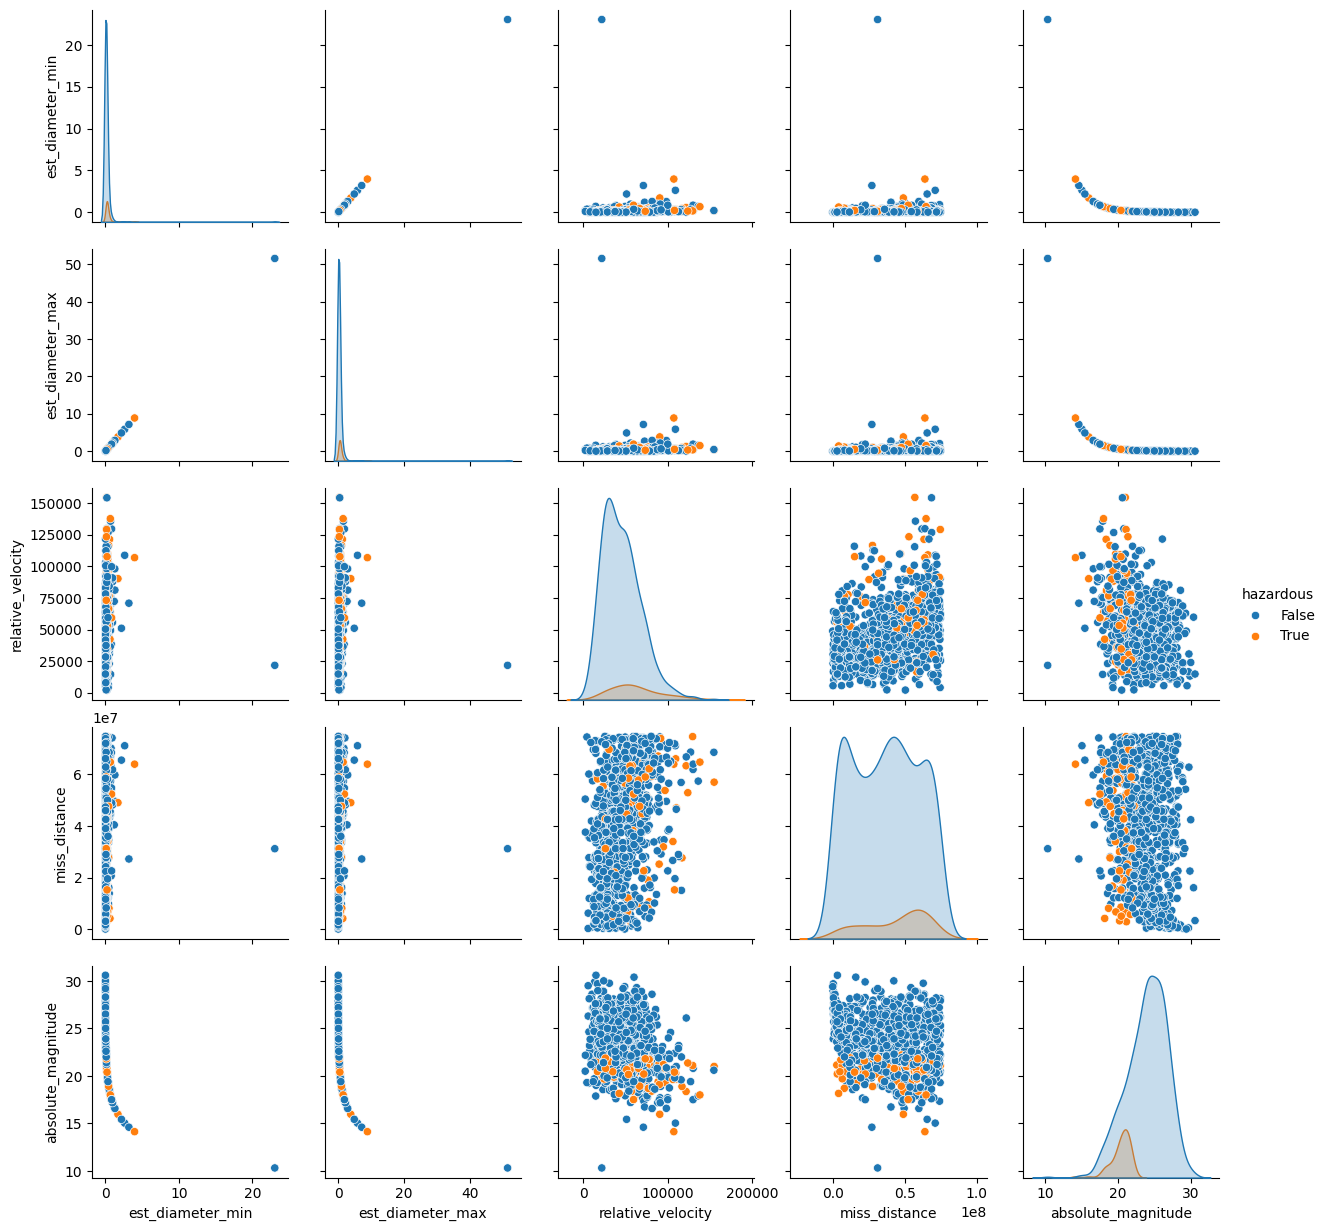

In [7]:

df_sample = df.sample(n=1000, random_state=42)

fig = sns.pairplot(
    df_sample[numeric_df + ['hazardous']],
    hue='hazardous',
    palette={False: "#1f77b4", True: "#ff7f0e"}
)

Hazardous objects cluster at absolute_magnitude values under 22 (larger, brighter objects), making size the primary factor for classification while velocity and distance act as secondary features.

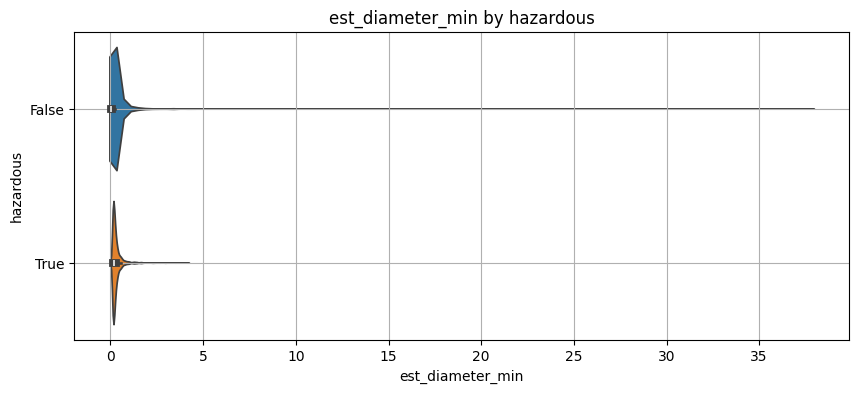

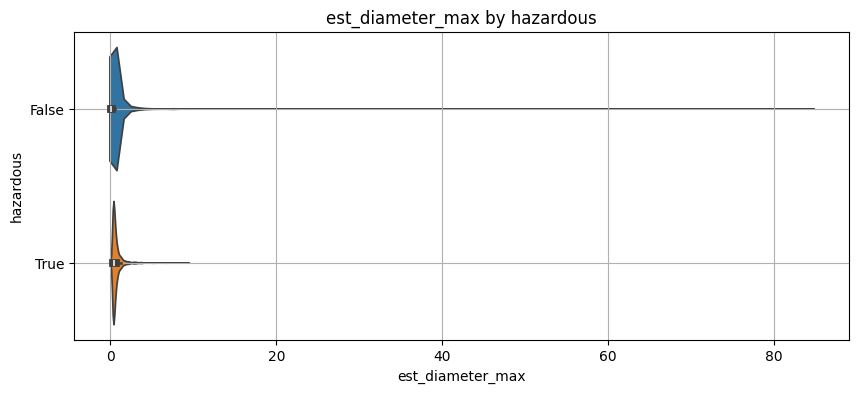

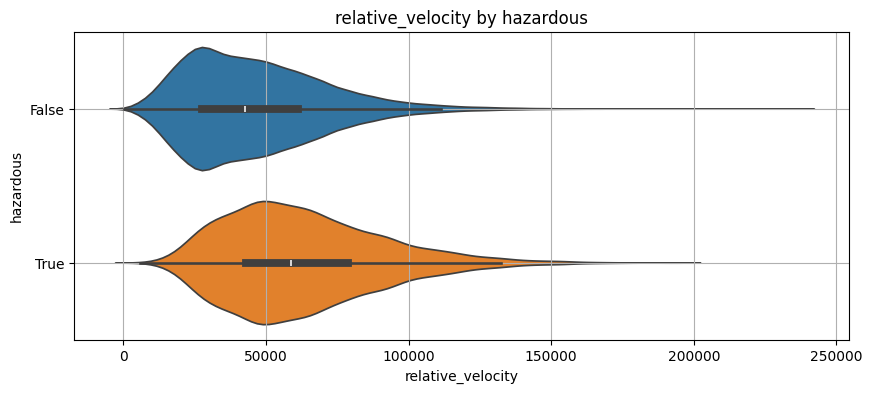

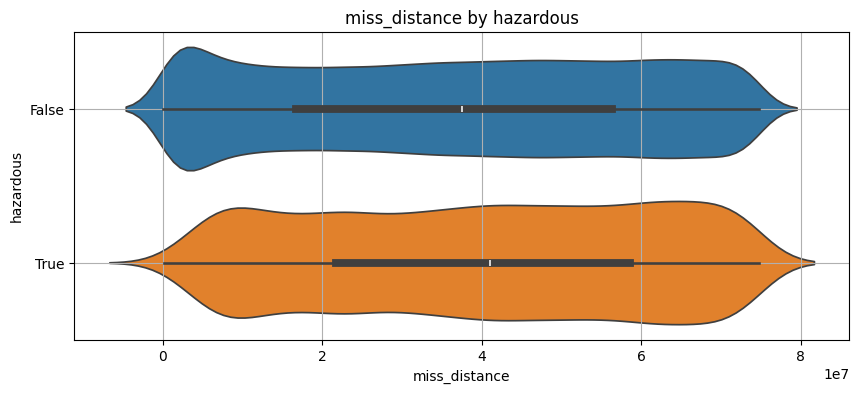

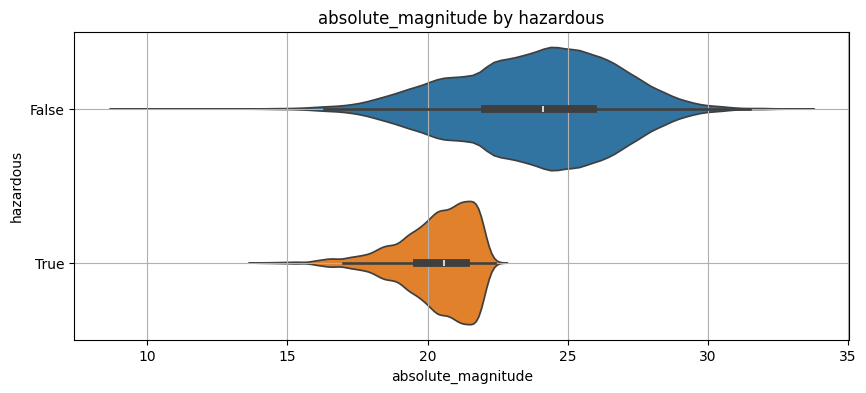

In [8]:
for k in numeric_df:
    plt.figure(figsize=(10, 4))

    sns.violinplot(
        data=df,
        x=k,
        y='hazardous',
        hue='hazardous',
        orient='h',
        legend=False
    )

    title = k + ' by hazardous'
    plt.title(title)
    plt.grid(True)
    plt.show()

Violin Plots display both the distribution density and key summary statistics (median and quartiles) for each numeric feature split by hazardous status.

# Data Preprocessing

In [9]:
df_cleaned.isnull().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
absolute_magnitude,0
hazardous,0


- No missing values were found, so no imputation was required.

In [10]:
print(df_cleaned.duplicated().sum())

0


- No duplicated values were found.

In [11]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   absolute_magnitude  90836 non-null  float64
 7   hazardous           90836 non-null  bool   
dtypes: bool(1), float64(5), int64(1), object(1)
memory usage: 4.9+ MB


In [12]:
print(df_cleaned.columns)

Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'absolute_magnitude',
       'hazardous'],
      dtype='object')


In [13]:
df_cleaned = df_cleaned.drop(columns=['id', 'name'])

df_cleaned.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,16.73,False
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,True
2,0.722030,1.614507,114258.692129,4.979872e+07,17.83,False
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,False
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,True


 - The id and name columns were removed because they uniquely identify each asteroid and do not provide useful predictive information.

In [14]:
df_cleaned['hazardous'] = df_cleaned['hazardous'].astype(int)

- The target variable was converted from Boolean values (True/False) to numeric values (1/0) to make it compatible with machine learning algorithms.

In [15]:
df_cleaned['hazardous'].value_counts()

,count
hazardous,
0,81996
1,8840


In [16]:
X = df_cleaned.drop('hazardous', axis=1)

y = df_cleaned['hazardous']

In [17]:
print(y.value_counts())

hazardous
0    81996
1     8840
Name: count, dtype: int64


- We examined the class distribution to determine whether the dataset is imbalanced before training the models.

- As shown the dataset is imbalanced.

In [18]:
from imblearn.over_sampling import SMOTE

#smote = SMOTE(random_state=42)

#X_balanced, y_balanced = smote.fit_resample(X, y)

- SMOTE was applied to generate synthetic samples for the minority class, resulting in a balanced dataset and reducing model bias.

In [19]:
#print(y_balanced.value_counts())

In [20]:
"""X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42
)"""

'X_train, X_test, y_train, y_test = train_test_split(\n    X_balanced,\n    y_balanced,\n    test_size=0.2,\n    random_state=42\n)'

In [21]:
"""scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)"""

'scaler = StandardScaler()\n\nX_train = scaler.fit_transform(X_train)\nX_test = scaler.transform(X_test)'

In [22]:
"""print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)"""

'print("X_train:", X_train.shape)\nprint("X_test :", X_test.shape)\nprint("y_train:", y_train.shape)\nprint("y_test :", y_test.shape)'

- we verified the dimensions of the training and testing datasets to ensure that the preprocessing pipeline was completed successfully.

In [23]:
#new
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
#new
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

X_train shape: (72668, 5)
X_test shape : (18168, 5)

Training distribution:
hazardous
0    65596
1     7072
Name: count, dtype: int64

Testing distribution:
hazardous
0    16400
1     1768
Name: count, dtype: int64


In [25]:
#new
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

- SMOTE was applied only to the training set to balance the minority class without changing the testing data.

In [26]:
#new
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

print("\nTest set remains unchanged:")
print(y_test.value_counts())

Before SMOTE:
hazardous
0    65596
1     7072
Name: count, dtype: int64

After SMOTE:
hazardous
0    65596
1    65596
Name: count, dtype: int64

Test set remains unchanged:
hazardous
0    16400
1     1768
Name: count, dtype: int64


In [27]:
#new
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

- StandardScaler was fitted on the balanced training data and then applied to the testing data using the same scaling parameters.

# Training

In [28]:
# X_train changed to X_train_scaled , X_test changed to X_test_scaled and y_train changed to t_train_balanced
XGB = XGBClassifier(random_state=42)
XGB.fit(X_train_scaled, y_train_balanced)
y_pred = XGB.predict(X_test_scaled)
Acc_XGBC = accuracy_score(y_test, y_pred)
print("Accuracy:", Acc_XGBC)

Accuracy: 0.8665785997357992


In [29]:
KNeighborsClassifier = KNeighborsClassifier()
KNeighborsClassifier.fit(X_train_scaled, y_train_balanced)
y_pred = KNeighborsClassifier.predict(X_test_scaled)
Acc_KNN = accuracy_score(y_test, y_pred)
print("Accuracy:", Acc_KNN)

Accuracy: 0.8246367239101717


In [30]:
RF= RandomForestClassifier(random_state=42)
RF.fit(X_train_scaled, y_train_balanced)
y_pred = RF.predict(X_test_scaled)
Acc_RF = accuracy_score(y_test, y_pred)
print("Accuracy:", Acc_RF)

Accuracy: 0.913364156759137


In [31]:
GNB= GaussianNB()
GNB.fit(X_train_scaled, y_train_balanced)
y_pred = GNB.predict(X_test_scaled)
Acc_GNB = accuracy_score(y_test, y_pred)
print("Accuracy:", Acc_GNB)

Accuracy: 0.7801629238221048


In [32]:
DTC= DecisionTreeClassifier(random_state=42)
DTC.fit(X_train, y_train)
y_pred = DTC.predict(X_test_scaled)
Acc_DTC = accuracy_score(y_test, y_pred)
print("Accuracy:", Acc_DTC)


Accuracy: 0.8484698370761778


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


so the baseline that the notebook have was

```
# Model	Score
1	XG Boost            	   91.14
2	Gaussian Naive Bayes       89.59
0	Random Forest      	       89.48
4	DecisionTreeClassifier	   89.00
3	KNeighborsClassifier	   87.51
```



In [33]:
model = pd.DataFrame({
     'Model': ['Random Forest', 'XG Boost', 'Gaussian Naive Bayes',
              'KNeighborsClassifier', 'DecisionTreeClassifier'],
    'Score': [Acc_RF, Acc_XGBC, Acc_GNB,
              Acc_KNN, Acc_DTC]})
model.sort_values(by='Score', ascending=False)

,Model,Score
0,Random Forest,0.913364
1,XG Boost,0.866579
4,DecisionTreeClassifier,0.848470
3,KNeighborsClassifier,0.824637
2,Gaussian Naive Bayes,0.780163


In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Random Forest": RF,
    "Decision Tree": DTC,
    "XGBoost": XGB,
    "KNN": KNeighborsClassifier,
    "GaussianNB": GNB
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    print(f"\n{name}")
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1-score:", f1_score(y_test, y_pred, average='weighted'))


Random Forest
Precision: 0.9124949842591372
Recall: 0.913364156759137
F1-score: 0.9129212907546167

Decision Tree
Precision: 0.8648712729212159
Recall: 0.8484698370761778
F1-score: 0.8560994645730872

XGBoost
Precision: 0.904243657297577
Recall: 0.8665785997357992
F1-score: 0.8809483310292217


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



KNN
Precision: 0.9170808480526199
Recall: 0.8246367239101717
F1-score: 0.8543422616479236

GaussianNB
Precision: 0.9200911432453648
Recall: 0.7801629238221048
F1-score: 0.8223088184972496


#Try to improve the model

In [35]:
# since Random Forest has the best score , we will apply tunning for more improvment
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled,
    y_train_balanced,
    train_size=40000,
    stratify=y_train_balanced,
    random_state=42
)

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [100, 200],
    "max_depth": [20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_tune, y_tune)

print("Best Parameters:")
print(random_search.best_params_)

best_rf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42
)

best_rf.fit(X_train_scaled, y_train_balanced)
y_pred = best_rf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy after tuning:", accuracy)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Accuracy after tuning: 0.9146301188903567


In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled,
    y_train_balanced,
    train_size=40000,
    stratify=y_train_balanced,
    random_state=42
)


rf = RandomForestClassifier(random_state=42)


param_grid = {
    "n_estimators": [150, 200, 250],
    "max_depth": [None],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)


grid_search.fit(X_tune, y_tune)


print("Best Parameters:")
print(grid_search.best_params_)


best_rf = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=42
)

best_rf.fit(X_train_scaled, y_train_balanced)


y_pred = best_rf.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy after Grid Search:", accuracy)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


KeyboardInterrupt: 

In [37]:
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score


cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0
)


cat.fit(X_train_scaled, y_train_balanced)


y_pred = cat.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)

print("CatBoost Accuracy:", accuracy)

ModuleNotFoundError: No module named 'catboost'

In [38]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


stack = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', XGB),
        ('dt', DTC),
        ('cat', cat)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)


stack.fit(X_train_scaled, y_train_balanced)


y_pred = stack.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Stacking Accuracy:", accuracy)

NameError: name 'cat' is not defined

In [39]:
from sklearn.metrics import classification_report

y_pred = best_rf.predict(X_test_scaled)

print(classification_report(y_test, y_pred))


IndexError: list index out of range

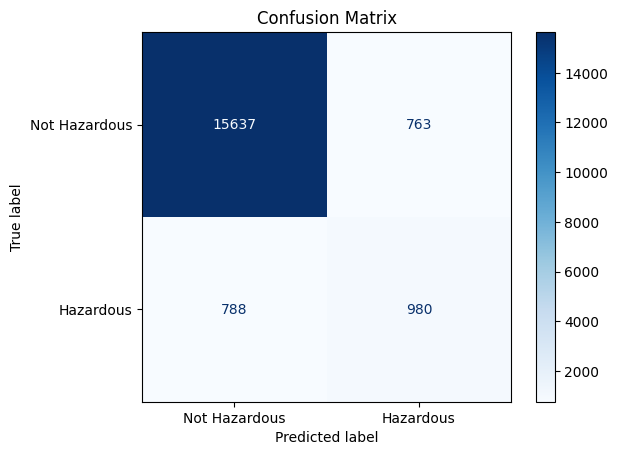

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Hazardous", "Hazardous"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [41]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

print("AUC:", roc_auc)

IndexError: list index out of range

In [42]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_rf,
    X_train_scaled,
    y_train_balanced,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

KeyboardInterrupt: 

              Feature  Importance
0    est_diameter_min         0.0
1    est_diameter_max         0.0
2   relative_velocity         0.0
3       miss_distance         0.0
4  absolute_magnitude         0.0


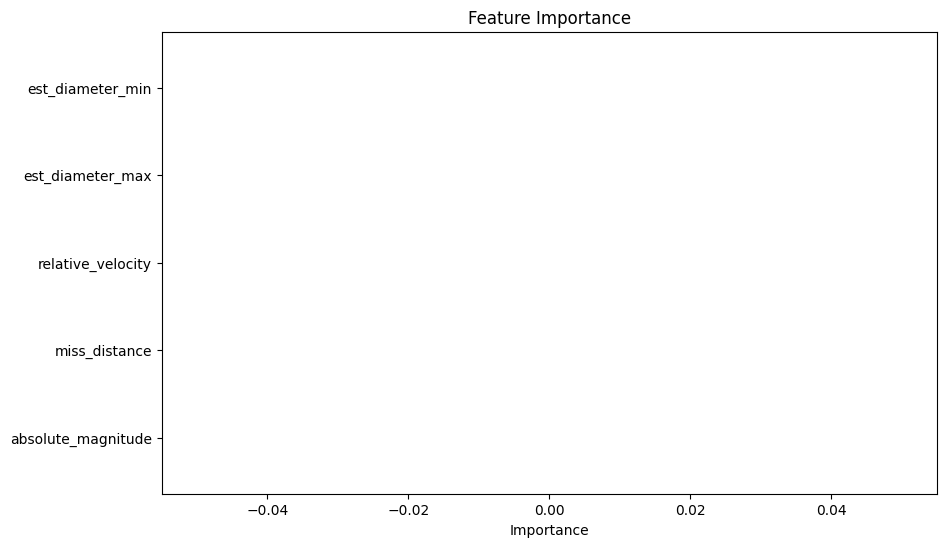

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

# Deployment

First Save the model

In [44]:
import joblib

# Save the tuned Random Forest model
joblib.dump(best_rf, 'neo_model.pkl')

# Save the fitted scaler (needed to transform live NASA data the same way)
joblib.dump(scaler, 'neo_scaler.pkl')

# Save the exact feature order the model expects
feature_order = list(X.columns)
joblib.dump(feature_order, 'neo_feature_order.pkl')

print("Saved:", feature_order)

Saved: ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']


In [45]:
from google.colab import files

files.download('neo_model.pkl')
files.download('neo_scaler.pkl')
files.download('neo_feature_order.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>